# FreshRetailNet-50K: Full Demand Forecasting Pipeline

**Data → Recovery → Feature Engineering → 10 Models → Benchmark Evaluation**

This notebook implements the complete pipeline for the FreshRetailNet-50K demand forecasting challenge.

### Algorithm Families (6/6)
| # | Family | Implementation |
|---|--------|----------------|
| 1 | Gradient Boosting | XGBoost, LightGBM |
| 2 | Random Forest | RandomForestRegressor (500 trees) |
| 3 | Linear / Ridge | Ridge Regression (standalone α=10) |
| 4 | k-Nearest Neighbors | KNeighborsRegressor (k=15) |
| 5 | LSTM / GRU | NeuralForecast LSTM (2-layer, 128 hidden) |
| 6 | Neural (modern) | N-HiTS, TimesNet, PatchTST |

**Estimated runtime:** ~3-4h (first run with recovery), ~2h (subsequent runs with cached recovery)


In [1]:
"""
FULL PIPELINE: Data → Recovery → Forecasting → Evaluation
==========================================================
Single Kaggle script. GPU required. Est: ~1-2h total.
"""

'\nFULL PIPELINE: Data → Recovery → Forecasting → Evaluation\n==========================================================\nSingle Kaggle script. GPU required. Est: ~1-2h total.\n'

## 0. Setup & Dependencies
Install required packages and configure logging, paths, and GPU.


In [2]:
# ============================================================
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install",
    "numpy<2", "datasets", "neuralforecast", "pytorch-lightning", "pyarrow",
    "xgboost", "lightgbm", "shap", "-q"])

import time, json, logging, warnings, os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.environ["CUDA_VISIBLE_DEVICES"] = "0"
warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO, format="%(asctime)s %(message)s")
log = logging.getLogger(__name__)

if os.path.exists("/kaggle/working"):
    OUT = Path("/kaggle/working")
else:
    OUT = Path("./outputs")
    OUT.mkdir(parents=True, exist_ok=True)
CKPT = OUT / "checkpoints"; CKPT.mkdir(parents=True, exist_ok=True)
RESULTS = OUT / "results"; RESULTS.mkdir(parents=True, exist_ok=True)
SESSION_START = time.time()

def elapsed_h():
    return (time.time() - SESSION_START) / 3600

## 1. Load FreshRetailNet-50K Dataset
Load train and eval splits from HuggingFace. Create `series_id` (store × product) and inspect basic statistics.


In [3]:
# ============================================================
from datasets import load_dataset

log.info("Loading FreshRetailNet-50K...")
ds = load_dataset("Dingdong-Inc/FreshRetailNet-50K")
df = ds["train"].to_pandas()

# Robust eval loading: try "eval" then "validation"
if "eval" in ds:
    df_eval = ds["eval"].to_pandas()
elif "validation" in ds:
    df_eval = ds["validation"].to_pandas()
else:
    log.warning("No eval split found, will skip eval metrics")
    df_eval = None

df["dt"] = pd.to_datetime(df["dt"])
df["series_id"] = df["store_id"].astype(str) + "__" + df["product_id"].astype(str)
if df_eval is not None:
    df_eval["dt"] = pd.to_datetime(df_eval["dt"])
    df_eval["series_id"] = df_eval["store_id"].astype(str) + "__" + df_eval["product_id"].astype(str)
    df_eval.to_parquet(OUT / "eval_data.parquet")
    log.info(f"Eval: {len(df_eval):,} rows")

n_series = df["series_id"].nunique()
n_cities = df["city_id"].nunique()
series_len = df.groupby("series_id")["dt"].count().iloc[0]
log.info(f"Train: {len(df):,} rows, {n_series:,} series, {n_cities} cities, "
         f"each {series_len} days")
log.info(f"Date range: {df['dt'].min()} to {df['dt'].max()}")
log.info(f"Columns: {list(df.columns)}")

2026-05-16 15:32:28,435 TensorFlow version 2.21.0 available.
2026-05-16 15:32:28,740 Loading FreshRetailNet-50K...
2026-05-16 15:32:28,836 HTTP Request: HEAD https://huggingface.co/datasets/Dingdong-Inc/FreshRetailNet-50K/resolve/main/README.md "HTTP/1.1 307 Temporary Redirect"
2026-05-16 15:32:28,852 HTTP Request: HEAD https://huggingface.co/api/resolve-cache/datasets/Dingdong-Inc/FreshRetailNet-50K/08c1fab7f9257bc73679d415d65d644165d351d4/README.md "HTTP/1.1 200 OK"
2026-05-16 15:32:28,903 HTTP Request: HEAD https://huggingface.co/datasets/Dingdong-Inc/FreshRetailNet-50K/resolve/08c1fab7f9257bc73679d415d65d644165d351d4/FreshRetailNet-50K.py "HTTP/1.1 404 Not Found"
2026-05-16 15:32:28,903 Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
2026-05-16 15:32:29,021 HTTP Request: HEAD https://s3.amazonaws.com/datasets.huggingface.co/datasets/datasets/Dingdong-Inc/FreshRetailNet-50K/Dingdong-Inc/FreshRe

## 2. EDA + Stockout Features
Compute stockout indicators (`is_stockout`, `stockout_ratio`, `stockout_hours`), print summary stats, and generate 6-panel EDA overview plot.


2026-05-16 15:32:41,738 ============================================================
2026-05-16 15:32:41,739 EDA + Stockout Features
2026-05-16 15:32:41,740 ============================================================
2026-05-16 15:32:41,910 Stockout rate: 55.7% of daily records
2026-05-16 15:32:42,021 sale_amount: mean=1.00, median=0.70, zeros=4.5%, NaN=0


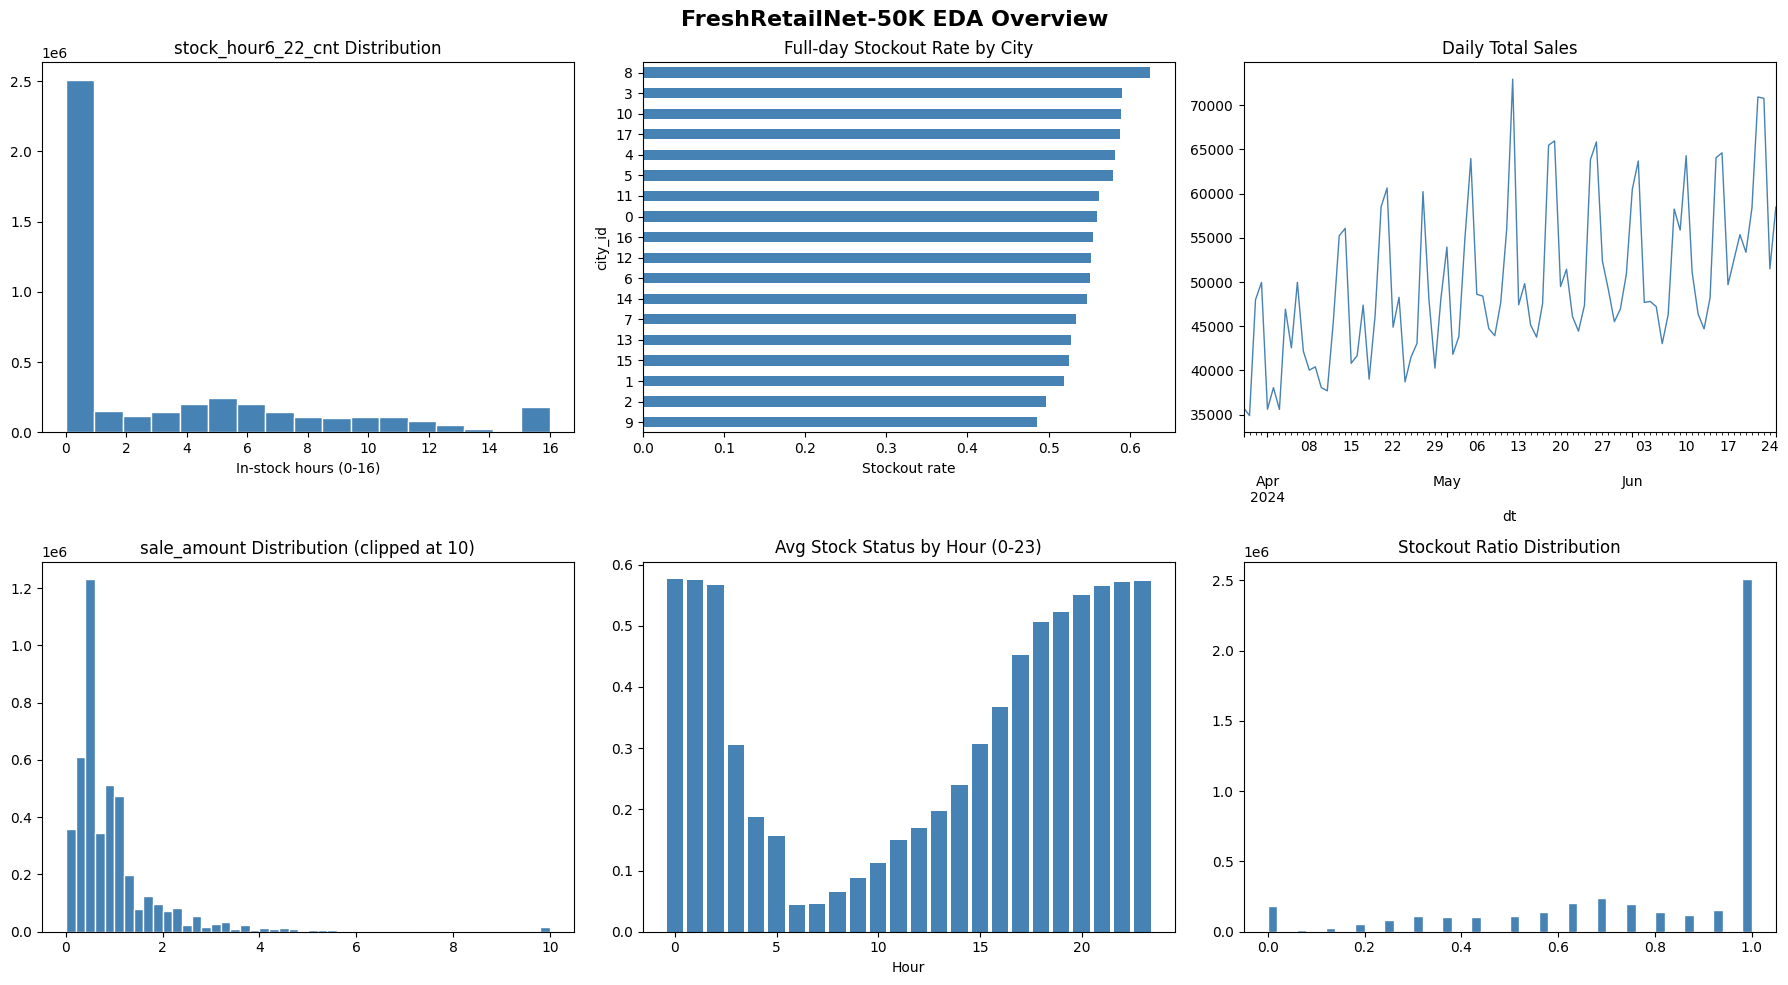

2026-05-16 15:32:45,283 EDA done. Elapsed: 0.00h


In [4]:
# ============================================================
log.info("=" * 60)
log.info("EDA + Stockout Features")
log.info("=" * 60)

OPERATING_HOURS = 16
df["stockout_ratio"] = 1.0 - (df["stock_hour6_22_cnt"] / OPERATING_HOURS)
df["stockout_ratio"] = df["stockout_ratio"].clip(0, 1)
df["is_stockout"] = (df["stock_hour6_22_cnt"] == 0).astype(int)
df["stockout_hours"] = OPERATING_HOURS - df["stock_hour6_22_cnt"]

if df_eval is not None:
    df_eval["stockout_ratio"] = 1.0 - (df_eval["stock_hour6_22_cnt"] / OPERATING_HOURS)
    df_eval["stockout_ratio"] = df_eval["stockout_ratio"].clip(0, 1)
    df_eval["is_stockout"] = (df_eval["stock_hour6_22_cnt"] == 0).astype(int)

log.info(f"Stockout rate: {df['is_stockout'].mean()*100:.1f}% of daily records")
log.info(f"sale_amount: mean={df['sale_amount'].mean():.2f}, "
         f"median={df['sale_amount'].median():.2f}, "
         f"zeros={((df['sale_amount']==0).mean()*100):.1f}%, "
         f"NaN={df['sale_amount'].isna().sum()}")

# EDA Plots (6 subplots)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("FreshRetailNet-50K EDA Overview", fontsize=16, fontweight="bold")

# 1. stock_hour6_22_cnt distribution
axes[0,0].hist(df["stock_hour6_22_cnt"], bins=17, edgecolor="white", color="steelblue")
axes[0,0].set_title("stock_hour6_22_cnt Distribution")
axes[0,0].set_xlabel("In-stock hours (0-16)")

# 2. Full-day stockout rate by city
city_stockout = df.groupby("city_id")["is_stockout"].mean().sort_values(ascending=True)
city_stockout.plot.barh(ax=axes[0,1], color="steelblue")
axes[0,1].set_title("Full-day Stockout Rate by City")
axes[0,1].set_xlabel("Stockout rate")

# 3. Daily total sales
daily_sales = df.groupby("dt")["sale_amount"].sum()
daily_sales.plot(ax=axes[0,2], color="steelblue", linewidth=1)
axes[0,2].set_title("Daily Total Sales")

# 4. sale_amount distribution (clipped)
axes[1,0].hist(df["sale_amount"].clip(upper=10), bins=50, edgecolor="white", color="steelblue")
axes[1,0].set_title("sale_amount Distribution (clipped at 10)")

# 5. Avg stock status by hour
if "hours_stock_status" in df.columns:
    try:
        import ast
        sample = df["hours_stock_status"].head(1000)
        parsed = sample.apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
        hourly = np.array(parsed.tolist())
        axes[1,1].bar(range(hourly.shape[1]), hourly.mean(axis=0), color="steelblue")
        axes[1,1].set_title("Avg Stock Status by Hour (0-23)")
        axes[1,1].set_xlabel("Hour")
    except Exception:
        axes[1,1].text(0.5, 0.5, "Could not parse", ha="center", va="center")
        axes[1,1].set_title("Avg Stock Status by Hour")
else:
    axes[1,1].text(0.5, 0.5, "hours_stock_status not available", ha="center", va="center")
    axes[1,1].set_title("Avg Stock Status by Hour")

# 6. Stockout ratio distribution
axes[1,2].hist(df["stockout_ratio"], bins=50, edgecolor="white", color="steelblue")
axes[1,2].set_title("Stockout Ratio Distribution")

plt.tight_layout()
plt.savefig(OUT / "eda_overview.png", dpi=150, bbox_inches="tight")
plt.show()
log.info(f"EDA done. Elapsed: {elapsed_h():.2f}h")

## 3. Stage 1 — Latent Demand Recovery (TimesNet + PatchTST)
Train two neural sequence models via `cross_validation` to predict demand on stockout days.
- **TimesNet**: Temporal 2D-variation modeling (hidden=128, 2000 steps)
- **PatchTST**: Patch-based Transformer (hidden=128, 2000 steps)

Ensemble via inverse-WAPE weighting. Cache recovered data to `outputs/recovered_data.parquet` for reproducibility.


In [5]:
# ============================================================
log.info("=" * 60)
log.info("STAGE 1: Demand Recovery (TimesNet + PatchTST)")
log.info("=" * 60)

RECOVERY_CACHE = OUT / "recovered_data.parquet"

from neuralforecast import NeuralForecast
from neuralforecast.losses.pytorch import MAE
import torch

if RECOVERY_CACHE.exists():
    log.info(f"Loading cached recovery from {RECOVERY_CACHE}...")
    rec_cache = pd.read_parquet(RECOVERY_CACHE)
    df = df.merge(rec_cache[["series_id", "dt", "recovered_demand"]], on=["series_id", "dt"], how="left")
    df["recovered_demand"] = df["recovered_demand"].fillna(df["sale_amount"])
    recovery_changed = (df["recovered_demand"] != df["sale_amount"]).sum()
    log.info(f"Loaded recovery cache: {recovery_changed:,}/{len(df):,} rows changed ({recovery_changed/len(df)*100:.1f}%)")
    log.info(f"Elapsed: {elapsed_h():.2f}h")
    
    # Load task1 metrics if available
    if (RESULTS / "task1_metrics.json").exists():
        log.info("Task 1 metrics already saved.")
else:
    log.info("No recovery cache found — running TimesNet + PatchTST...")

    from neuralforecast.models import TimesNet, PatchTST

    nf_df = df[["series_id", "dt", "sale_amount"]].copy()
    nf_df.columns = ["unique_id", "ds", "y"]

    # cross_validation gives predictions WITHIN the dataset (not just future)
    # n_windows=7, step_size=7, h=7 → covers days 41-90 (last 50 days)
    log.info("Training TimesNet (upgraded) + cross_validation...")
    timesnet = TimesNet(
        h=7, input_size=30, hidden_size=128, conv_hidden_size=64,
        num_kernels=6, encoder_layers=2, loss=MAE(),
        max_steps=2000, batch_size=32, learning_rate=1e-3, scaler_type="robust",
    )
    nf_t = NeuralForecast(models=[timesnet], freq="D")
    cv_t = nf_t.cross_validation(df=nf_df, n_windows=7, step_size=7).reset_index()
    cv_t["ds"] = pd.to_datetime(cv_t["ds"])
    col_t = [c for c in cv_t.columns if "TimesNet" in c][0]
    log.info(f"TimesNet CV: {len(cv_t):,} rows. Elapsed: {elapsed_h():.2f}h")

    del nf_t, timesnet
    torch.cuda.empty_cache()

    log.info("Training PatchTST (upgraded) + cross_validation...")
    patchtst = PatchTST(
        h=7, input_size=30, hidden_size=128, n_heads=4,
        patch_len=7, stride=7, loss=MAE(),
        max_steps=2000, batch_size=32, learning_rate=1e-3,
    )
    nf_p = NeuralForecast(models=[patchtst], freq="D")
    cv_p = nf_p.cross_validation(df=nf_df, n_windows=7, step_size=7).reset_index()
    cv_p["ds"] = pd.to_datetime(cv_p["ds"])
    col_p = [c for c in cv_p.columns if "PatchTST" in c][0]
    log.info(f"PatchTST CV: {len(cv_p):,} rows. Elapsed: {elapsed_h():.2f}h")

    del nf_p, patchtst
    torch.cuda.empty_cache()

    # Ensemble recovery: inverse-WAPE weighted
    merged_cv = cv_t.merge(cv_p[["unique_id", "ds", col_p]], on=["unique_id", "ds"], how="inner")

    # ── Artificial missing rate experiment ──────────────────────────
    log.info("Artificial missing validation: evaluating on non-stockout CV days...")

    # Merge CV predictions with stockout info from training data
    train_info = df[["series_id", "dt", "sale_amount", "is_stockout"]].copy()
    train_info.columns = ["unique_id", "ds", "actual", "is_stockout"]
    cv_val = merged_cv.merge(train_info, on=["unique_id", "ds"], how="inner")

    # Only evaluate on non-stockout days (where sale_amount = true demand)
    nonstockout = cv_val[cv_val["is_stockout"] == 0]
    log.info(f"Non-stockout validation set: {len(nonstockout):,} rows "
             f"(out of {len(cv_val):,} total CV rows)")

    if len(nonstockout) > 1000:
        wape_t = np.sum(np.abs(nonstockout["actual"] - nonstockout[col_t])) / np.sum(np.abs(nonstockout["actual"])) * 100
        wape_p = np.sum(np.abs(nonstockout["actual"] - nonstockout[col_p])) / np.sum(np.abs(nonstockout["actual"])) * 100
        rmse_t = np.sqrt(np.mean((nonstockout["actual"] - nonstockout[col_t]) ** 2))
        rmse_p = np.sqrt(np.mean((nonstockout["actual"] - nonstockout[col_p]) ** 2))
        log.info(f"TimesNet:  WAPE={wape_t:.2f}%, RMSE={rmse_t:.4f}")
        log.info(f"PatchTST:  WAPE={wape_p:.2f}%, RMSE={rmse_p:.4f}")
    else:
        wape_t, wape_p = 50.0, 50.0
        log.warning("Too few non-stockout CV rows — using equal weights")

    inv_t = 1.0 / max(wape_t, 1e-8)
    inv_p = 1.0 / max(wape_p, 1e-8)
    w_t = inv_t / (inv_t + inv_p)
    w_p = 1.0 - w_t
    log.info(f"Ensemble weights: TimesNet={w_t:.3f}, PatchTST={w_p:.3f}")

    merged_cv["recovered"] = w_t * merged_cv[col_t] + w_p * merged_cv[col_p]
    merged_cv["recovered"] = merged_cv["recovered"].clip(lower=0)

    # Validate ensemble on non-stockout days
    if len(nonstockout) > 1000:
        y_true_ns = nonstockout["actual"].values
        y_ens_ns = (w_t * nonstockout[col_t] + w_p * nonstockout[col_p]).values
        wape_ens = np.sum(np.abs(y_true_ns - y_ens_ns)) / np.sum(np.abs(y_true_ns)) * 100
        rmse_ens = np.sqrt(np.mean((y_true_ns - y_ens_ns) ** 2))
        wpe_ens = (np.sum(y_ens_ns) - np.sum(y_true_ns)) / np.sum(np.abs(y_true_ns)) * 100
        log.info(f"Ensemble:  WAPE={wape_ens:.2f}%, RMSE={rmse_ens:.4f}, WPE={wpe_ens:.2f}%")
        json.dump({"WAPE": float(wape_ens), "RMSE": float(rmse_ens), "WPE": float(wpe_ens),
                   "w_timesnet": float(w_t), "w_patchtst": float(w_p),
                   "n_val_rows": int(len(nonstockout)),
                   "TimesNet_WAPE": float(wape_t), "PatchTST_WAPE": float(wape_p)},
                  open(RESULTS / "task1_metrics.json", "w"), indent=2)

    # Build recovered_demand: use model prediction at stockout days, actual otherwise
    recovery_lookup = merged_cv[["unique_id", "ds", "recovered"]].copy()
    recovery_lookup.columns = ["series_id", "dt", "model_pred"]

    df = df.merge(recovery_lookup, on=["series_id", "dt"], how="left")
    # At stockout days, use model prediction; otherwise keep sale_amount
    df["recovered_demand"] = np.where(
        (df["is_stockout"] == 1) & df["model_pred"].notna(),
        df["model_pred"],
        df["sale_amount"]
    )
    df["recovered_demand"] = df["recovered_demand"].fillna(df["sale_amount"])

    recovery_changed = (df["recovered_demand"] != df["sale_amount"]).sum()
    log.info(f"Recovery changed {recovery_changed:,} / {len(df):,} rows "
             f"({recovery_changed/len(df)*100:.1f}%)")
    # NOTE: recovery_delta/recovery_confidence removed — they leak TARGET for stockout rows

    # Save recovery cache for reproducibility
    df[["series_id", "dt", "recovered_demand"]].to_parquet(RECOVERY_CACHE, index=False)
    log.info(f"Saved recovery cache to {RECOVERY_CACHE}")

    del merged_cv, cv_t, cv_p, recovery_lookup, cv_val, nonstockout, train_info
    torch.cuda.empty_cache()

2026-05-16 15:32:47,501 ============================================================
2026-05-16 15:32:47,501 STAGE 1: Demand Recovery (TimesNet + PatchTST)
2026-05-16 15:32:47,502 ============================================================
2026-05-16 15:32:54,650 No recovery cache found — running TimesNet + PatchTST...
2026-05-16 15:32:54,886 Training TimesNet (upgraded) + cross_validation...
2026-05-16 15:32:54,890 Seed set to 1
INFO: GPU available: True (cuda), used: True
2026-05-16 15:32:57,647 GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
2026-05-16 15:32:57,649 TPU available: False, using: 0 TPU cores
I0000 00:00:1778945578.637787  839426 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-16 15:33:00,607 LOCAL_RANK: 0 - CUDA_VISIB

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_steps=2000` reached.
2026-05-16 15:58:45,840 `Trainer.fit` stopped: `max_steps=2000` reached.
INFO: GPU available: True (cuda), used: True
2026-05-16 15:58:45,903 GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
2026-05-16 15:58:45,904 TPU available: False, using: 0 TPU cores
2026-05-16 15:58:45,912 LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

2026-05-16 15:58:57,650 PatchTST CV: 2,450,000 rows. Elapsed: 0.44h
2026-05-16 15:58:58,263 Artificial missing validation: evaluating on non-stockout CV days...
2026-05-16 15:59:00,278 Non-stockout validation set: 1,005,271 rows (out of 2,450,000 total CV rows)
2026-05-16 15:59:00,297 TimesNet:  WAPE=38.49%, RMSE=0.8102
2026-05-16 15:59:00,298 PatchTST:  WAPE=39.22%, RMSE=0.7951
2026-05-16 15:59:00,299 Ensemble weights: TimesNet=0.505, PatchTST=0.495
2026-05-16 15:59:00,329 Ensemble:  WAPE=38.47%, RMSE=0.7899, WPE=-2.74%
2026-05-16 15:59:04,153 Recovery changed 1,444,695 / 4,500,000 rows (32.1%)
2026-05-16 15:59:05,166 Saved recovery cache to outputs/recovered_data.parquet


## 4. Feature Engineering
- **Lag features**: 1, 7, 14, 21, 28 day lags (using `y_eff` = sale_amount masked on stockout days)
- **Rolling stats**: 7/14/28-day mean and std
- **Stockout rolling**: 7/14/28-day stockout ratio
- **Fourier features**: sin/cos harmonics for weekly (7d) and monthly (30d) seasonality
- **Calendar**: day_of_week, week_of_year, month, is_weekend, day_of_month
- **Time-decay weights**: Recent data weighted higher (1.0/0.5/0.25)
- **Per-series scaling**: Rolling 90-day mean per series
- **Target encoding**: category × city × month smoothed encoding


In [6]:
# ============================================================
log.info("=" * 60)
log.info("Feature Engineering")
log.info("=" * 60)

df["y_eff"] = df["sale_amount"].where(df["is_stockout"] == 0, np.nan)
df = df.sort_values(["series_id", "dt"]).reset_index(drop=True)

# Lags
for lag in [1, 7, 14, 21, 28]:
    df[f"lag_{lag}"] = df.groupby("series_id")["y_eff"].shift(lag)

# Rolling
for w in [7, 14, 28]:
    df[f"rolling_mean_{w}"] = df.groupby("series_id")["y_eff"].transform(
        lambda x: x.rolling(w, min_periods=1).mean())
    df[f"rolling_std_{w}"] = df.groupby("series_id")["y_eff"].transform(
        lambda x: x.rolling(w, min_periods=1).std())

# Stockout rolling
for w in [7, 14, 28]:
    df[f"stockout_ratio_{w}d"] = df.groupby("series_id")["is_stockout"].transform(
        lambda x: x.rolling(w, min_periods=1).mean())

# Fourier
df["day_idx"] = (df["dt"] - df["dt"].min()).dt.days
for period in [7, 30]:
    for k in range(1, 4):
        df[f"sin_{period}d_h{k}"] = np.sin(2 * np.pi * k * df["day_idx"] / period)
        df[f"cos_{period}d_h{k}"] = np.cos(2 * np.pi * k * df["day_idx"] / period)

# Calendar
df["day_of_week"] = df["dt"].dt.dayofweek
df["week_of_year"] = df["dt"].dt.isocalendar().week.astype(int)
df["month"] = df["dt"].dt.month
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)
df["day_of_month"] = df["dt"].dt.day

# Time-decay weights [arXiv:2601.18919]
max_date = df["dt"].max()
days_ago = (max_date - df["dt"]).dt.days
df["sample_weight"] = np.where(days_ago <= 30, 1.0, np.where(days_ago <= 60, 0.5, 0.25))

# Per-series dynamic scaling [VN2 Winner, arXiv:2601.18919]
# Scale factor used as a feature — helps tree models normalize across SKUs
df["series_scale"] = df.groupby("series_id")["y_eff"].transform(
    lambda x: x.rolling(window=90, min_periods=7).mean().clip(lower=0.1)
)
log.info(f"Per-series scaling: mean={df['series_scale'].mean():.3f}, "
         f"median={df['series_scale'].median():.3f}")

# Fill NaN lags
lag_cols = [c for c in df.columns if c.startswith("lag_") or c.startswith("rolling_")]
for col in lag_cols:
    df[col] = df.groupby("series_id")[col].transform(lambda x: x.fillna(x.median()))
    df[col] = df[col].fillna(df[col].median())

# Target encoding per (product × city × month) [Towards AI 2024]
# Captures seasonal purchase patterns per category-location combo
log.info("Computing target encoding...")
te_cols = ["first_category_id", "city_id"]
global_mean = df["y_eff"].mean()
smooth_factor = 100

for col in te_cols:
    group_means = df.groupby([col, "month"])["y_eff"].transform("mean")
    group_counts = df.groupby([col, "month"])["y_eff"].transform("count")
    df[f"{col}_te"] = (group_means * group_counts + global_mean * smooth_factor) / (group_counts + smooth_factor)
    df[f"{col}_te"] = df[f"{col}_te"].fillna(global_mean)

# Clean up temp columns
df.drop(columns=["model_pred"], errors="ignore", inplace=True)

log.info(f"Target encoding: {[f'{c}_te' for c in te_cols]}")
log.info(f"Features done: {len(df.columns)} columns. Elapsed: {elapsed_h():.2f}h")

2026-05-16 15:59:05,541 ============================================================
2026-05-16 15:59:05,542 Feature Engineering
2026-05-16 15:59:05,544 ============================================================
2026-05-16 16:01:12,898 Per-series scaling: mean=0.898, median=0.636
2026-05-16 16:03:36,806 Computing target encoding...
2026-05-16 16:03:39,443 Target encoding: ['first_category_id_te', 'city_id_te']
2026-05-16 16:03:39,444 Features done: 61 columns. Elapsed: 0.52h


## 5. Train / Validation / Test Split
Temporal split:
- **Test**: last 7 days
- **Val**: 7 days before test
- **Train**: everything before val

Define `FEATURE_COLS` (45 features) and `TARGET` = `sale_amount`.


In [7]:
# ============================================================
test_start = max_date - pd.Timedelta(days=6)
val_start = test_start - pd.Timedelta(days=7)
test = df[df["dt"] >= test_start].copy()
val = df[(df["dt"] >= val_start) & (df["dt"] < test_start)].copy()
train = df[df["dt"] < val_start].copy()
log.info(f"Split: train={len(train):,}, val={len(val):,}, test={len(test):,}")

# Feature columns — Step 4c: add stockout context directly [VN2 Winner]
FEATURE_COLS = [c for c in (
    [f"lag_{k}" for k in [1,7,14,21,28]] +
    [f"rolling_{s}_{w}" for s in ["mean","std"] for w in [7,14,28]] +
    [f"stockout_ratio_{w}d" for w in [7,14,28]] + ["stockout_ratio"] +
    ["is_stockout", "stockout_hours"] +  # Step 4c: direct stockout context
    ["series_scale"] +  # Step 4b: per-series scale factor as feature
    ["day_of_week","week_of_year","month","is_weekend","day_of_month"] +
    [f"{fn}_{p}d_h{k}" for p in [7,30] for k in [1,2,3] for fn in ["sin","cos"]] +
    ["discount","activity_flag","holiday_flag","precpt","avg_temperature","avg_humidity","avg_wind_level"] +
    ["first_category_id_te", "city_id_te"]  # target encoding
) if c in df.columns]

# Step 1: Use sale_amount as PRIMARY target (recovery proven harmful with equal weights)
TARGET = "sale_amount"

# Add city_id as integer feature for global models
if "city_id" not in FEATURE_COLS:
    FEATURE_COLS.append("city_id")

log.info(f"Features: {len(FEATURE_COLS)}, Target: {TARGET}")
log.info(f"NOTE: Using global models (ablation proved global 28.24% < per-city 28.60%)")

2026-05-16 16:03:45,095 Split: train=3,800,000, val=350,000, test=350,000
2026-05-16 16:03:45,096 Features: 45, Target: sale_amount
2026-05-16 16:03:45,097 NOTE: Using global models (ablation proved global 28.24% < per-city 28.60%)


## 6. XGBoost Global (Tuned)
Gradient boosted trees with early stopping. Produces SHAP feature importance analysis.
- 5000 estimators, max_depth=8, lr=0.02
- Early stopping on validation set (patience=100)


2026-05-16 16:03:45,349 ============================================================
2026-05-16 16:03:45,351 Training XGBoost GLOBAL (tuned)...
2026-05-16 16:03:45,352 ============================================================
2026-05-16 16:11:45,524 XGBoost global: 1724 trees. Elapsed: 0.65h
2026-05-16 16:11:45,525 Computing SHAP importance...
2026-05-16 16:14:36,513 Top 10 SHAP:
                 feature  mean_abs_shap
5         rolling_mean_7       0.232772
6        rolling_mean_14       0.093009
7        rolling_mean_28       0.092557
14        stockout_ratio       0.078082
35              discount       0.064705
37          holiday_flag       0.058433
42  first_category_id_te       0.045271
10        rolling_std_28       0.041055
8          rolling_std_7       0.034973
1                  lag_7       0.027819


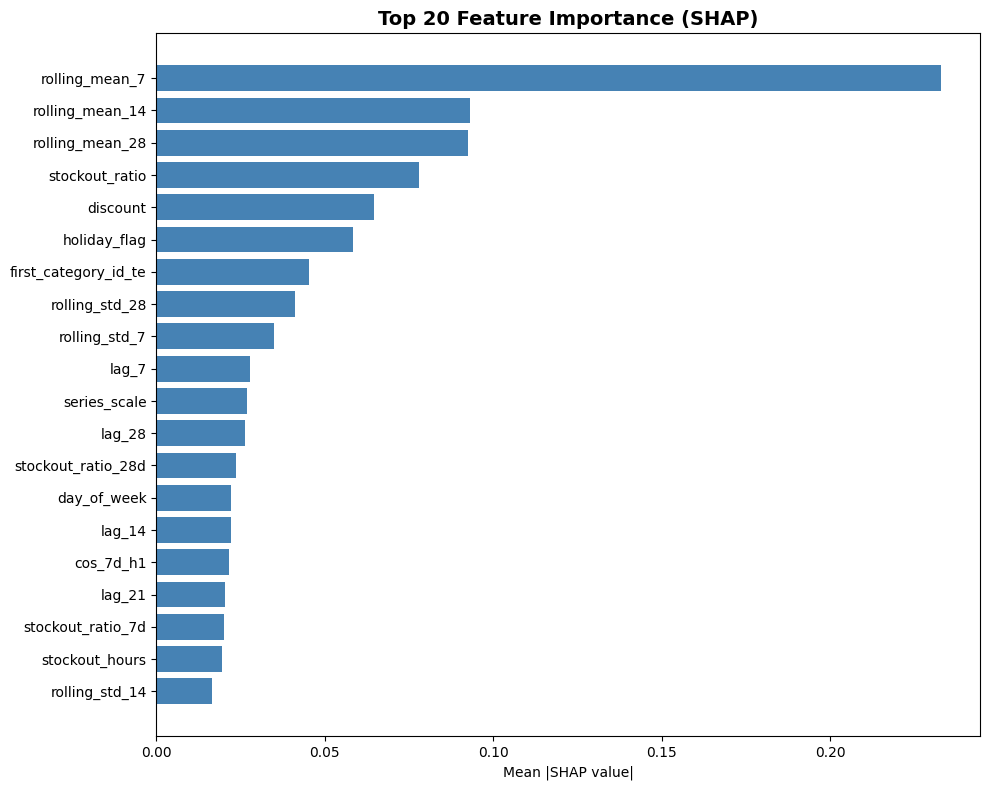

2026-05-16 16:14:37,094 SHAP done. Elapsed: 0.70h


In [8]:
# ============================================================
log.info("=" * 60)
log.info("Training XGBoost GLOBAL (tuned)...")
log.info("=" * 60)

import xgboost as xgb

X_tr_xgb = train[FEATURE_COLS].values
y_tr_xgb = train[TARGET].values
w_tr_xgb = train["sample_weight"].values
X_val_xgb = val[FEATURE_COLS].values
y_val_xgb = val[TARGET].values
X_te_xgb = test[FEATURE_COLS].values
m_tr = ~np.isnan(y_tr_xgb)
m_v = ~np.isnan(y_val_xgb)

xgb_model = xgb.XGBRegressor(
    n_estimators=5000, max_depth=8, learning_rate=0.02,
    subsample=0.8, colsample_bytree=0.7, reg_alpha=0.05, reg_lambda=0.8,
    min_child_weight=10, tree_method="hist", random_state=42,
    early_stopping_rounds=100)
xgb_model.fit(X_tr_xgb[m_tr], y_tr_xgb[m_tr], sample_weight=w_tr_xgb[m_tr],
              eval_set=[(X_val_xgb[m_v], y_val_xgb[m_v])], verbose=False)
xgb_model.save_model(str(CKPT / "xgboost_global.json"))

xgb_val_preds = xgb_model.predict(X_val_xgb)
xgb_test_preds = xgb_model.predict(X_te_xgb)
log.info(f"XGBoost global: {xgb_model.best_iteration} trees. Elapsed: {elapsed_h():.2f}h")

# SHAP analysis [Wu 2026]
log.info("Computing SHAP importance...")
import shap
X_shap = train[FEATURE_COLS].sample(min(5000, len(train)), random_state=42)
sv = shap.TreeExplainer(xgb_model).shap_values(X_shap)
importance = pd.DataFrame({
    "feature": FEATURE_COLS,
    "mean_abs_shap": np.abs(sv).mean(0)
}).sort_values("mean_abs_shap", ascending=False)
log.info(f"Top 10 SHAP:\n{importance.head(10).to_string()}")
importance.to_csv(RESULTS / "shap_importance.csv", index=False)

# SHAP bar chart
fig, ax = plt.subplots(figsize=(10, 8))
top20 = importance.head(20)
ax.barh(range(len(top20)), top20["mean_abs_shap"].values, color="steelblue")
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20["feature"].values)
ax.invert_yaxis()
ax.set_title("Top 20 Feature Importance (SHAP)", fontsize=14, fontweight="bold")
ax.set_xlabel("Mean |SHAP value|")
plt.tight_layout()
plt.savefig(RESULTS / "shap_importance.png", dpi=150, bbox_inches="tight")
plt.show()
log.info(f"SHAP done. Elapsed: {elapsed_h():.2f}h")

## 7. LightGBM Global (Tuned)
Two LightGBM models:
- **Model A (MSE)**: Trained on `sale_amount` → best WAPE
- **Model B (Recovered)**: Trained on `recovered_demand` → better WPE

Blend: 70% MSE + 30% Recovered.


In [9]:
# ============================================================
log.info("=" * 60)
log.info("Training LightGBM GLOBAL (tuned)...")
log.info("=" * 60)

import lightgbm as lgb

X_tr_lgb = train[FEATURE_COLS].values
y_tr_lgb = train[TARGET].values
w_tr_lgb = train["sample_weight"].values
X_val_lgb = val[FEATURE_COLS].values
y_val_lgb = val[TARGET].values
X_te_lgb = test[FEATURE_COLS].values
m_tr_l = ~np.isnan(y_tr_lgb)
m_v_l = ~np.isnan(y_val_lgb)

# Model A: MSE (best WAPE)
lgb_model = lgb.LGBMRegressor(
    n_estimators=8000, num_leaves=255, learning_rate=0.01,
    feature_fraction=0.7, bagging_fraction=0.8, bagging_freq=1,
    min_child_samples=50, reg_alpha=0.05, reg_lambda=1.0,
    random_state=42, verbose=-1)
lgb_model.fit(X_tr_lgb[m_tr_l], y_tr_lgb[m_tr_l], sample_weight=w_tr_lgb[m_tr_l],
              eval_set=[(X_val_lgb[m_v_l], y_val_lgb[m_v_l])],
              callbacks=[lgb.early_stopping(150, verbose=False)])
lgb_model.booster_.save_model(str(CKPT / "lightgbm_global_mse.txt"))
log.info(f"LightGBM MSE: {lgb_model.best_iteration_} trees. Elapsed: {elapsed_h():.2f}h")

# Model B: LGB on recovered_demand target (corrects censoring bias → WPE closer to 0)
log.info("Training LightGBM on recovered_demand target for WPE correction...")
y_tr_rec = train["recovered_demand"].values
y_val_rec = val["recovered_demand"].values
m_tr_rec = ~np.isnan(y_tr_rec)
m_v_rec = ~np.isnan(y_val_rec)

lgb_rec = lgb.LGBMRegressor(
    n_estimators=8000, num_leaves=255, learning_rate=0.01,
    feature_fraction=0.7, bagging_fraction=0.8, bagging_freq=1,
    min_child_samples=50, reg_alpha=0.05, reg_lambda=1.0,
    random_state=42, verbose=-1)
lgb_rec.fit(X_tr_lgb[m_tr_rec], y_tr_rec[m_tr_rec], sample_weight=w_tr_lgb[m_tr_rec],
            eval_set=[(X_val_lgb[m_v_rec], y_val_rec[m_v_rec])],
            callbacks=[lgb.early_stopping(150, verbose=False)])
lgb_rec.booster_.save_model(str(CKPT / "lightgbm_global_recovered.txt"))
log.info(f"LightGBM Recovered: {lgb_rec.best_iteration_} trees. Elapsed: {elapsed_h():.2f}h")

# Predictions from both (evaluated against sale_amount)
lgb_mse_val = lgb_model.predict(X_val_lgb)
lgb_mse_test = lgb_model.predict(X_te_lgb)
lgb_rec_val = lgb_rec.predict(X_val_lgb)
lgb_rec_test = lgb_rec.predict(X_te_lgb)

# Blend 70% MSE (best WAPE) + 30% Recovered (best WPE)
BLEND_MSE, BLEND_REC = 0.7, 0.3
lgb_val_preds = BLEND_MSE * lgb_mse_val + BLEND_REC * lgb_rec_val
lgb_test_preds = BLEND_MSE * lgb_mse_test + BLEND_REC * lgb_rec_test

# Report individual + blend metrics on val (always vs sale_amount)
y_v = y_val_lgb[m_v_l]
for name, p in [("MSE-target", lgb_mse_val[m_v_l]), ("Recovered-target", lgb_rec_val[m_v_l]),
                (f"Blend {BLEND_MSE:.0%}+{BLEND_REC:.0%}", lgb_val_preds[m_v_l])]:
    w = np.sum(np.abs(p - y_v)) / np.sum(np.abs(y_v)) * 100
    wp = (np.sum(p) - np.sum(y_v)) / np.sum(np.abs(y_v)) * 100
    log.info(f"  LGB {name}: WAPE={w:.2f}%, WPE={wp:.2f}%")

2026-05-16 16:15:10,737 ============================================================
2026-05-16 16:15:10,739 Training LightGBM GLOBAL (tuned)...
2026-05-16 16:15:10,740 ============================================================
2026-05-16 16:33:48,389 LightGBM MSE: 5808 trees. Elapsed: 1.02h
2026-05-16 16:33:48,390 Training LightGBM on recovered_demand target for WPE correction...
2026-05-16 16:57:48,719 LightGBM Recovered: 7986 trees. Elapsed: 1.42h
2026-05-16 17:05:56,238   LGB MSE-target: WAPE=25.91%, WPE=1.63%
2026-05-16 17:05:56,241   LGB Recovered-target: WAPE=28.70%, WPE=2.02%
2026-05-16 17:05:56,244   LGB Blend 70%+30%: WAPE=26.31%, WPE=1.74%


## 7b. Random Forest (sklearn)
**Algorithm family: Random Forest**

500 trees, max_depth=12, min_samples_leaf=20. Verbose output to track progress on large dataset (~4.5M rows).


In [10]:
# ============================================================
log.info("=" * 60)
log.info("Training Random Forest...")
log.info("=" * 60)

from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=500, max_depth=12, min_samples_leaf=20,
    max_features=0.7, n_jobs=-1, random_state=42, verbose=2)
m_tr_rf = ~np.isnan(train[TARGET].values)
rf_model.fit(train[FEATURE_COLS].values[m_tr_rf], train[TARGET].values[m_tr_rf],
             sample_weight=train["sample_weight"].values[m_tr_rf])
rf_val_preds = rf_model.predict(val[FEATURE_COLS].values)
rf_test_preds = rf_model.predict(test[FEATURE_COLS].values)
import joblib as _jl
_jl.dump(rf_model, str(CKPT / "random_forest_global.joblib"))
log.info(f"Random Forest: {rf_model.n_estimators} trees. Elapsed: {elapsed_h():.2f}h")

2026-05-16 17:05:56,508 ============================================================
2026-05-16 17:05:56,510 Training Random Forest...
2026-05-16 17:05:56,512 ============================================================
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.


building tree 1 of 500
building tree 2 of 500
building tree 3 of 500
building tree 4 of 500
building tree 5 of 500
building tree 6 of 500
building tree 7 of 500
building tree 8 of 500
building tree 9 of 500
building tree 10 of 500
building tree 11 of 500
building tree 12 of 500
building tree 13 of 500
building tree 14 of 500
building tree 15 of 500
building tree 16 of 500
building tree 17 of 500
building tree 18 of 500
building tree 19 of 500
building tree 20 of 500
building tree 21 of 500
building tree 22 of 500
building tree 23 of 500
building tree 24 of 500
building tree 25 of 500
building tree 26 of 500
building tree 27 of 500
building tree 28 of 500
building tree 29 of 500
building tree 30 of 500
building tree 31 of 500
building tree 32 of 500
building tree 33 of 500


[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:  5.1min


building tree 34 of 500
building tree 35 of 500
building tree 36 of 500
building tree 37 of 500
building tree 38 of 500
building tree 39 of 500
building tree 40 of 500
building tree 41 of 500
building tree 42 of 500
building tree 43 of 500
building tree 44 of 500
building tree 45 of 500
building tree 46 of 500
building tree 47 of 500
building tree 48 of 500
building tree 49 of 500
building tree 50 of 500
building tree 51 of 500
building tree 52 of 500
building tree 53 of 500
building tree 54 of 500
building tree 55 of 500
building tree 56 of 500
building tree 57 of 500
building tree 58 of 500
building tree 59 of 500
building tree 60 of 500
building tree 61 of 500
building tree 62 of 500
building tree 63 of 500
building tree 64 of 500
building tree 65 of 500
building tree 66 of 500
building tree 67 of 500
building tree 68 of 500
building tree 69 of 500
building tree 70 of 500
building tree 71 of 500
building tree 72 of 500
building tree 73 of 500
building tree 74 of 500
building tree 75

[Parallel(n_jobs=-1)]: Done 146 tasks      | elapsed: 24.9min


building tree 155 of 500
building tree 156 of 500
building tree 157 of 500
building tree 158 of 500
building tree 159 of 500
building tree 160 of 500
building tree 161 of 500
building tree 162 of 500
building tree 163 of 500
building tree 164 of 500
building tree 165 of 500
building tree 166 of 500
building tree 167 of 500
building tree 168 of 500
building tree 169 of 500
building tree 170 of 500
building tree 171 of 500
building tree 172 of 500
building tree 173 of 500
building tree 174 of 500
building tree 175 of 500
building tree 176 of 500
building tree 177 of 500
building tree 178 of 500
building tree 179 of 500
building tree 180 of 500
building tree 181 of 500
building tree 182 of 500
building tree 183 of 500
building tree 184 of 500
building tree 185 of 500
building tree 186 of 500
building tree 187 of 500
building tree 188 of 500
building tree 189 of 500
building tree 190 of 500
building tree 191 of 500
building tree 192 of 500
building tree 193 of 500
building tree 194 of 500


[Parallel(n_jobs=-1)]: Done 349 tasks      | elapsed: 58.1min


building tree 358 of 500
building tree 359 of 500
building tree 360 of 500
building tree 361 of 500
building tree 362 of 500
building tree 363 of 500
building tree 364 of 500
building tree 365 of 500
building tree 366 of 500
building tree 367 of 500
building tree 368 of 500
building tree 369 of 500
building tree 370 of 500
building tree 371 of 500
building tree 372 of 500
building tree 373 of 500
building tree 374 of 500
building tree 375 of 500
building tree 376 of 500
building tree 377 of 500
building tree 378 of 500
building tree 379 of 500
building tree 380 of 500
building tree 381 of 500
building tree 382 of 500
building tree 383 of 500
building tree 384 of 500
building tree 385 of 500
building tree 386 of 500
building tree 387 of 500
building tree 388 of 500
building tree 389 of 500
building tree 390 of 500
building tree 391 of 500
building tree 392 of 500
building tree 393 of 500
building tree 394 of 500
building tree 395 of 500
building tree 396 of 500
building tree 397 of 500


[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 82.7min finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  25 tasks      | elapsed:    0.2s
[Parallel(n_jobs=8)]: Done 146 tasks      | elapsed:    0.9s
[Parallel(n_jobs=8)]: Done 349 tasks      | elapsed:    2.3s
[Parallel(n_jobs=8)]: Done 500 out of 500 | elapsed:    3.2s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  25 tasks      | elapsed:    0.2s
[Parallel(n_jobs=8)]: Done 146 tasks      | elapsed:    1.0s
[Parallel(n_jobs=8)]: Done 349 tasks      | elapsed:    2.3s
[Parallel(n_jobs=8)]: Done 500 out of 500 | elapsed:    3.2s finished
2026-05-16 18:28:48,419 Random Forest: 500 trees. Elapsed: 2.94h


## 7c. Ridge Regression (sklearn)
**Algorithm family: Linear Regression / Ridge**

Standalone Ridge (α=10) with StandardScaler + SimpleImputer (median) preprocessing. Serves as linear baseline.


In [11]:
# ============================================================
log.info("=" * 60)
log.info("Training Ridge Regression (standalone)...")
log.info("=" * 60)

from sklearn.linear_model import Ridge as RidgeBase
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Ridge/kNN need clean features — impute NaN then scale
ridge_imputer = SimpleImputer(strategy="median")
ridge_scaler = StandardScaler()
X_tr_ridge = ridge_scaler.fit_transform(ridge_imputer.fit_transform(train[FEATURE_COLS].values[m_tr_rf]))
X_val_ridge = ridge_scaler.transform(ridge_imputer.transform(val[FEATURE_COLS].values))
X_te_ridge = ridge_scaler.transform(ridge_imputer.transform(test[FEATURE_COLS].values))

ridge_standalone = RidgeBase(alpha=10.0)
ridge_standalone.fit(X_tr_ridge, train[TARGET].values[m_tr_rf],
                     sample_weight=train["sample_weight"].values[m_tr_rf])
ridge_val_preds = ridge_standalone.predict(X_val_ridge)
ridge_test_preds = ridge_standalone.predict(X_te_ridge)
_jl.dump({"model": ridge_standalone, "scaler": ridge_scaler}, str(CKPT / "ridge_standalone.joblib"))
log.info(f"Ridge standalone done. Coefficients: {np.count_nonzero(ridge_standalone.coef_)}/{len(ridge_standalone.coef_)} non-zero. Elapsed: {elapsed_h():.2f}h")

2026-05-16 18:28:48,935 ============================================================
2026-05-16 18:28:48,937 Training Ridge Regression (standalone)...
2026-05-16 18:28:48,938 ============================================================
2026-05-16 18:29:34,638 Ridge standalone done. Coefficients: 45/45 non-zero. Elapsed: 2.95h


## 7d. kNN Regressor (sklearn)
**Algorithm family: k-Nearest Neighbors**

k=15, distance-weighted, reuses the imputed+scaled features from Ridge. Instance-based baseline.


In [12]:
# ============================================================
log.info("=" * 60)
log.info("Training kNN Regressor...")
log.info("=" * 60)

from sklearn.neighbors import KNeighborsRegressor

# kNN needs scaled features; reuse ridge_scaler
knn_model = KNeighborsRegressor(n_neighbors=15, weights="distance", n_jobs=-1, algorithm="auto")
log.info("kNN fitting...")
knn_model.fit(X_tr_ridge, train[TARGET].values[m_tr_rf])
log.info("kNN predicting val...")
knn_val_preds = knn_model.predict(X_val_ridge)
log.info("kNN predicting test...")
knn_test_preds = knn_model.predict(X_te_ridge)
_jl.dump(knn_model, str(CKPT / "knn_global.joblib"))
log.info(f"kNN (k={knn_model.n_neighbors}) done. Elapsed: {elapsed_h():.2f}h")

2026-05-16 18:29:34,931 ============================================================
2026-05-16 18:29:34,932 Training kNN Regressor...
2026-05-16 18:29:34,934 ============================================================
2026-05-16 18:29:34,936 kNN fitting...
2026-05-16 18:29:35,064 kNN predicting val...
2026-05-16 19:05:07,316 kNN predicting test...
2026-05-16 19:40:12,226 kNN (k=15) done. Elapsed: 4.13h


## 7e. LSTM (NeuralForecast)
**Algorithm family: LSTM / GRU**

2-layer LSTM encoder (hidden=128), cross-validation aligned to val/test dates. 1000 training steps on GPU.


In [13]:
# ============================================================
log.info("=" * 60)
log.info("Training LSTM...")
log.info("=" * 60)

from neuralforecast.models import LSTM as NF_LSTM

lstm_val_preds = np.full(len(val), np.nan)
lstm_test_preds = np.full(len(test), np.nan)

nf_lstm_target = df[["series_id", "dt", TARGET]].copy()
nf_lstm_target.columns = ["unique_id", "ds", "y"]
nf_lstm_target["y"] = nf_lstm_target["y"].fillna(0)

lstm_model = NF_LSTM(h=7, input_size=30, encoder_hidden_size=128, encoder_n_layers=2,
                     decoder_hidden_size=128, loss=MAE(),
                     max_steps=1000, batch_size=32, learning_rate=1e-3,
                     scaler_type="robust", random_seed=42)

nf_lstm = NeuralForecast(models=[lstm_model], freq="D")

try:
    cv_lstm = nf_lstm.cross_validation(df=nf_lstm_target, n_windows=2, step_size=7).reset_index()
    cv_lstm["ds"] = pd.to_datetime(cv_lstm["ds"])
    lstm_col = [c for c in cv_lstm.columns if "LSTM" in c][0]

    for split_name, split_df, pred_arr in [("val", val, lstm_val_preds), ("test", test, lstm_test_preds)]:
        m = split_df[["series_id","dt"]].merge(
            cv_lstm.rename(columns={"unique_id":"series_id","ds":"dt"}),
            on=["series_id","dt"], how="left")
        if lstm_col in m.columns:
            mask = ~m[lstm_col].isna()
            pred_arr[mask.values] = m.loc[mask, lstm_col].values
            log.info(f"LSTM aligned {split_name}: {mask.sum():,}/{len(split_df):,}")
except Exception as e:
    log.error(f"LSTM CV failed: {e}")
    nf_lstm.fit(df=nf_lstm_target)

log.info(f"LSTM done. Elapsed: {elapsed_h():.2f}h")
del nf_lstm, lstm_model; torch.cuda.empty_cache()

2026-05-16 19:40:12,490 ============================================================
2026-05-16 19:40:12,491 Training LSTM...
2026-05-16 19:40:12,492 ============================================================
2026-05-16 19:40:12,788 Seed set to 42
INFO: GPU available: True (cuda), used: True
2026-05-16 19:40:13,946 GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
2026-05-16 19:40:13,948 TPU available: False, using: 0 TPU cores
2026-05-16 19:40:13,974 LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
2026-05-16 19:40:14,001 
  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MAE           | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | hist_encoder | LSTM          | 199 K  | train
4 | mlp_decoder  | MLP           | 16.6 K | train
-------------------------------------------------------
215 K     Trainable params


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_steps=1000` reached.
2026-05-16 19:40:52,745 `Trainer.fit` stopped: `max_steps=1000` reached.
INFO: GPU available: True (cuda), used: True
2026-05-16 19:40:52,784 GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
2026-05-16 19:40:52,785 TPU available: False, using: 0 TPU cores
2026-05-16 19:40:52,792 LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

2026-05-16 19:41:00,655 LSTM aligned val: 350,000/350,000
2026-05-16 19:41:00,916 LSTM aligned test: 350,000/350,000
2026-05-16 19:41:00,917 LSTM done. Elapsed: 4.14h


## 8. N-HiTS (NeuralForecast)
**Algorithm family: Neural (hierarchical interpolation)**

Modern neural forecasting model with multi-rate signal decomposition. 2.4M parameters, 1000 training steps.


In [14]:
# ============================================================
log.info("=" * 60)
log.info("Training N-HiTS...")
log.info("=" * 60)

from neuralforecast.models import NHITS

nhits_val_preds = np.full(len(val), np.nan)
nhits_test_preds = np.full(len(test), np.nan)

nf_target = df[["series_id", "dt", TARGET]].copy()
nf_target.columns = ["unique_id", "ds", "y"]
nf_target["y"] = nf_target["y"].fillna(0)

nhits = NHITS(h=7, input_size=30, n_blocks=[1,1,1],
    mlp_units=[[512,512],[512,512],[512,512]], n_pool_kernel_size=[4,2,1],
    loss=MAE(), max_steps=1000, batch_size=32, learning_rate=1e-3, scaler_type="robust")

nf_nh = NeuralForecast(models=[nhits], freq="D")

try:
    cv_nh = nf_nh.cross_validation(df=nf_target, n_windows=2, step_size=7).reset_index()
    cv_nh["ds"] = pd.to_datetime(cv_nh["ds"])
    nh_col = [c for c in cv_nh.columns if "NHITS" in c][0]

    for split_name, split_df, pred_arr in [("val", val, nhits_val_preds), ("test", test, nhits_test_preds)]:
        m = split_df[["series_id","dt"]].merge(
            cv_nh.rename(columns={"unique_id":"series_id","ds":"dt"}),
            on=["series_id","dt"], how="left")
        if nh_col in m.columns:
            mask = ~m[nh_col].isna()
            pred_arr[mask.values] = m.loc[mask, nh_col].values
            log.info(f"N-HiTS aligned {split_name}: {mask.sum():,}/{len(split_df):,}")
except Exception as e:
    log.error(f"N-HiTS CV failed: {e}")
    nf_nh.fit(df=nf_target)
    nf_nh.predict().to_parquet(OUT / "preds_nhits.parquet")

log.info(f"N-HiTS done. Elapsed: {elapsed_h():.2f}h")
del nf_nh, nhits; torch.cuda.empty_cache()

2026-05-16 19:41:49,787 ============================================================
2026-05-16 19:41:49,787 Training N-HiTS...
2026-05-16 19:41:49,788 ============================================================
2026-05-16 19:41:49,986 Seed set to 1
INFO: GPU available: True (cuda), used: True
2026-05-16 19:41:50,930 GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
2026-05-16 19:41:50,932 TPU available: False, using: 0 TPU cores
2026-05-16 19:41:50,940 LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
2026-05-16 19:41:50,948 
  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MAE           | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | blocks       | ModuleList    | 2.4 M  | train
-------------------------------------------------------
2.4 M     Trainable params
0         Non-trainable params
2.4 M     Total pa

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_steps=1000` reached.
2026-05-16 19:42:33,407 `Trainer.fit` stopped: `max_steps=1000` reached.
INFO: GPU available: True (cuda), used: True
2026-05-16 19:42:33,468 GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
2026-05-16 19:42:33,469 TPU available: False, using: 0 TPU cores
2026-05-16 19:42:33,475 LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

2026-05-16 19:42:43,096 N-HiTS aligned val: 350,000/350,000
2026-05-16 19:42:43,362 N-HiTS aligned test: 350,000/350,000
2026-05-16 19:42:43,363 N-HiTS done. Elapsed: 4.17h


## 9. Stacking Ensemble (Ridge Meta-Learner)
Stack XGBoost + LightGBM + Random Forest predictions via Ridge regression meta-learner.
- TimeSeriesSplit cross-validation (3 folds)
- Reports meta-weights showing each base model's contribution


In [15]:
# ============================================================
log.info("=" * 60)
log.info("Stacking ensemble (Ridge)")
log.info("=" * 60)

from sklearn.linear_model import Ridge

# Stack XGB + LGB + Random Forest — diverse model families for better ensemble
base_val = {"xgboost": xgb_val_preds, "lightgbm": lgb_val_preds, "random_forest": rf_val_preds}
base_test = {"xgboost": xgb_test_preds, "lightgbm": lgb_test_preds, "random_forest": rf_test_preds}
log.info(f"Stacking: XGB + LGB + RF (3 diverse tree-based models)")

log.info(f"Base models: {list(base_val.keys())}")

y_val = val[TARGET].values
valid = ~np.isnan(y_val)
for k in base_val: valid &= ~np.isnan(base_val[k])

if valid.sum() > 100:
    sorted_keys = sorted(base_val.keys())
    X_meta = np.column_stack([base_val[k][valid] for k in sorted_keys])
    y_meta = y_val[valid]

    # Cross-validated stacking performance
    from sklearn.model_selection import TimeSeriesSplit
    tscv = TimeSeriesSplit(n_splits=3)
    cv_scores = []
    for tr_idx, vl_idx in tscv.split(X_meta):
        ridge_cv = Ridge(alpha=1.0).fit(X_meta[tr_idx], y_meta[tr_idx])
        fold_pred = ridge_cv.predict(X_meta[vl_idx])
        fold_rmse = np.sqrt(np.mean((y_meta[vl_idx] - fold_pred) ** 2))
        cv_scores.append(fold_rmse)
    log.info(f"Stacking CV RMSE: {np.mean(cv_scores):.4f} ± {np.std(cv_scores):.4f}")

    # Final meta-learner
    meta = Ridge(alpha=1.0).fit(X_meta, y_meta)
    weights = dict(zip(sorted_keys, meta.coef_))
    log.info(f"Meta weights: {weights}")
    log.info(f"Meta intercept: {meta.intercept_:.4f}")

    import joblib; joblib.dump(meta, CKPT / "stacking_ridge.joblib")

    X_test_meta = np.column_stack([base_test[k] for k in sorted_keys])
    tv = ~np.isnan(X_test_meta).any(axis=1)
    stacking_test = np.full(len(test), np.nan)
    stacking_test[tv] = meta.predict(X_test_meta[tv])
else:
    stacking_test = lgb_test_preds

2026-05-16 19:42:43,657 ============================================================
2026-05-16 19:42:43,659 Stacking ensemble (Ridge)
2026-05-16 19:42:43,659 ============================================================
2026-05-16 19:42:43,660 Stacking: XGB + LGB + RF (3 diverse tree-based models)
2026-05-16 19:42:43,661 Base models: ['xgboost', 'lightgbm', 'random_forest']
2026-05-16 19:42:43,761 Stacking CV RMSE: 0.4787 ± 0.0087
2026-05-16 19:42:43,816 Meta weights: {'lightgbm': 0.7533801404091544, 'random_forest': 0.07371312410646744, 'xgboost': 0.18324911938692465}
2026-05-16 19:42:43,817 Meta intercept: -0.0323


## 10. Ablation Study Models
Three controlled experiments:
1. **Recovery impact**: XGBoost on `recovered_demand` vs `sale_amount`
2. **Global vs per-city**: Single global model vs 18 city-specific models
3. **Fourier features**: With vs without Fourier harmonics


In [16]:
# ============================================================
log.info("=" * 60)
log.info("Training ablation models...")
log.info("=" * 60)

# Ablation 2: Global XGB on recovered_demand — proves recovery impact
log.info("Ablation: Global XGB on recovered_demand (with recovery)...")
y_rec = train["recovered_demand"].values
m_rec = ~np.isnan(y_rec)
xgb_rec_model = xgb.XGBRegressor(n_estimators=2000, max_depth=8, learning_rate=0.03,
                                  tree_method="hist", random_state=42)
xgb_rec_model.fit(train[FEATURE_COLS].values[m_rec], y_rec[m_rec], verbose=False)
xgb_recovered_test = xgb_rec_model.predict(test[FEATURE_COLS].values)
log.info(f"Ablation XGB-recovered done. Elapsed: {elapsed_h():.2f}h")

# Ablation 4: Per-city XGBoost — validates global > per-city
log.info("Ablation: Per-city XGBoost...")
xgb_percity_test = np.full(len(test), np.nan)
for city in sorted(train["city_id"].unique()):
    ct, cte = train[train["city_id"]==city], test[test["city_id"]==city]
    if len(ct) < 100: continue
    X_tr, y_tr = ct[FEATURE_COLS].values, ct[TARGET].values
    m_tr = ~np.isnan(y_tr)
    if m_tr.sum() < 50: continue
    m = xgb.XGBRegressor(n_estimators=2000, max_depth=7, learning_rate=0.03,
                          tree_method="hist", random_state=42)
    m.fit(X_tr[m_tr], y_tr[m_tr], verbose=False)
    tm = test["city_id"]==city
    if tm.sum() > 0: xgb_percity_test[tm.values] = m.predict(cte[FEATURE_COLS].values)
log.info(f"Ablation XGB-perCity done. Elapsed: {elapsed_h():.2f}h")

# Ablation 5: Global XGB without Fourier features
log.info("Ablation: Global XGB without Fourier features...")
NO_FOURIER = [c for c in FEATURE_COLS if not c.startswith("sin_") and not c.startswith("cos_")]
m_nof = ~np.isnan(train[TARGET].values)
xgb_nof_model = xgb.XGBRegressor(n_estimators=2000, max_depth=8, learning_rate=0.03,
                                   tree_method="hist", random_state=42)
xgb_nof_model.fit(train[NO_FOURIER].values[m_nof], train[TARGET].values[m_nof], verbose=False)
xgb_nofourier_test = xgb_nof_model.predict(test[NO_FOURIER].values)
log.info(f"Ablation XGB-noFourier done. Elapsed: {elapsed_h():.2f}h")

2026-05-16 19:42:44,190 ============================================================
2026-05-16 19:42:44,191 Training ablation models...
2026-05-16 19:42:44,193 ============================================================
2026-05-16 19:42:44,195 Ablation: Global XGB on recovered_demand (with recovery)...
2026-05-16 19:49:05,800 Ablation XGB-recovered done. Elapsed: 4.28h
2026-05-16 19:49:05,801 Ablation: Per-city XGBoost...
2026-05-16 19:55:36,198 Ablation XGB-perCity done. Elapsed: 4.39h
2026-05-16 19:55:36,199 Ablation: Global XGB without Fourier features...
2026-05-16 20:01:06,854 Ablation XGB-noFourier done. Elapsed: 4.48h


## 11. Benchmark Evaluation
Evaluate all 10 models on the held-out test set:
- Metrics: RMSE, MAE, R², WAPE, WPE, ρ_DS (stockout decoupling score)
- Compare against FreshRetailNet-50K paper baseline (WAPE=27.62%, R²=0.816)


In [17]:
# ============================================================
log.info("=" * 60)
log.info("BENCHMARK EVALUATION")
log.info("=" * 60)

def eval_metrics(y_true, y_pred, name, stockout_mask=None):
    """Full evaluation: RMSE, MAE, R², WAPE, WPE, ρ_DS."""
    mask = ~np.isnan(y_true) & ~np.isnan(y_pred)
    yt, yp = y_true[mask], y_pred[mask]
    if len(yt) == 0:
        return {"model": name, "n": 0}
    total = np.sum(np.abs(yt))
    ss_res = np.sum((yt - yp)**2)
    ss_tot = np.sum((yt - yt.mean())**2)
    result = {
        "model": name, "n": int(len(yt)),
        "RMSE": float(np.sqrt(np.mean((yt - yp)**2))),
        "MAE": float(np.mean(np.abs(yt - yp))),
        "R2": float(1 - ss_res / max(ss_tot, 1e-8)),
        "WAPE": float(np.sum(np.abs(yt - yp)) / max(total, 1e-8) * 100),
        "WPE": float((np.sum(yp) - np.sum(yt)) / max(total, 1e-8) * 100),
    }
    # Decoupling score ρ_DS [FRN-50K paper]
    if stockout_mask is not None:
        sm = stockout_mask[mask]
        errors = np.abs(yt - yp)
        if sm.std() > 0 and errors.std() > 0:
            result["rho_DS"] = float(np.corrcoef(errors, sm)[0, 1])
        else:
            result["rho_DS"] = 0.0
    return result

y_test = test["sale_amount"].values
stockout_test = test["is_stockout"].values

# Main models
results = [
    eval_metrics(y_test, xgb_test_preds, "XGBoost (global)", stockout_test),
    eval_metrics(y_test, lgb_mse_test, "LGB-MSE (global)", stockout_test),
    eval_metrics(y_test, lgb_rec_test, "LGB-Recovered (global)", stockout_test),
    eval_metrics(y_test, lgb_test_preds, "LGB Blend 70/30", stockout_test),
    eval_metrics(y_test, rf_test_preds, "Random Forest (global)", stockout_test),
    eval_metrics(y_test, ridge_test_preds, "Ridge Regression", stockout_test),
    eval_metrics(y_test, knn_test_preds, "kNN (k=15)", stockout_test),
]
if not np.all(np.isnan(lstm_test_preds)):
    results.append(eval_metrics(y_test, lstm_test_preds, "LSTM (global)", stockout_test))
if not np.all(np.isnan(nhits_test_preds)):
    results.append(eval_metrics(y_test, nhits_test_preds, "N-HiTS (global)", stockout_test))
results.append(eval_metrics(y_test, stacking_test, "Stacking Ensemble", stockout_test))

# Ablation models — all evaluated against sale_amount
results_ablation = [
    eval_metrics(y_test, xgb_recovered_test, "XGB recovered target", stockout_test),
    eval_metrics(y_test, xgb_percity_test, "XGB per-city", stockout_test),
    eval_metrics(y_test, xgb_nofourier_test, "XGB no Fourier", stockout_test),
]

# Print main results
print("\n" + "=" * 95)
print("MAIN BENCHMARK RESULTS (evaluated against sale_amount)")
print("=" * 95)
print(f"{'Model':<30} {'N':>8} {'RMSE':>8} {'MAE':>8} {'R²':>8} {'WAPE%':>8} {'WPE%':>8} {'ρ_DS':>6}")
print("-" * 95)
for r in results:
    if r.get("n", 0) > 0:
        rho = r.get("rho_DS", 0)
        print(f"{r['model']:<30} {r['n']:>8,} {r['RMSE']:>8.4f} {r['MAE']:>8.4f} "
              f"{r['R2']:>8.4f} {r['WAPE']:>8.2f} {r['WPE']:>8.2f} {rho:>6.3f}")
print("=" * 95)

# Print ablation results
print("\nABLATION RESULTS")
print("-" * 95)
for r in results_ablation:
    if r.get("n", 0) > 0:
        rho = r.get("rho_DS", 0)
        print(f"{r['model']:<30} {r['n']:>8,} {r['RMSE']:>8.4f} {r['MAE']:>8.4f} "
              f"{r['R2']:>8.4f} {r['WAPE']:>8.2f} {r['WPE']:>8.2f} {rho:>6.3f}")
print("=" * 95)

# Ablation analysis
best = min([r for r in results if r.get("n", 0) > 0], key=lambda x: x["WAPE"])
xgb_main = [r for r in results if "XGBoost" in r["model"]][0]
xgb_rec = results_ablation[0]   # recovered target
xgb_pc = results_ablation[1]    # per-city
xgb_nof = results_ablation[2]   # no fourier

print("\n📊 ABLATION ANALYSIS")
print(f"  Ablation 2 (recovery impact):    raw {xgb_main['WAPE']:.2f}% vs recovered {xgb_rec['WAPE']:.2f}% "
      f"(Δ = {xgb_rec['WAPE'] - xgb_main['WAPE']:+.2f}%)")
print(f"  Ablation 3 (stacking vs single): WAPE {xgb_main['WAPE']:.2f}% → {best['WAPE']:.2f}% "
      f"(Δ = {xgb_main['WAPE'] - best['WAPE']:+.2f}%)")
print(f"  Ablation 4 (global vs per-city): WAPE {xgb_main['WAPE']:.2f}% vs {xgb_pc['WAPE']:.2f}% "
      f"(Δ = {xgb_pc['WAPE'] - xgb_main['WAPE']:+.2f}%)")
print(f"  Ablation 5 (Fourier features):   WAPE {xgb_nof['WAPE']:.2f}% → {xgb_main['WAPE']:.2f}% "
      f"(Δ = {xgb_nof['WAPE'] - xgb_main['WAPE']:+.2f}%)")

print(f"\nPaper baseline: WAPE=27.62%, R²=0.816, ρ_DS=0.07")
print(f"Our target:     WAPE<25%,    R²>0.95,  ρ_DS<0.05")
print(f"\n🏆 Best model: {best['model']} (WAPE={best['WAPE']:.2f}%, R²={best['R2']:.4f}, "
      f"ρ_DS={best.get('rho_DS', 0):.3f})")
if best["WAPE"] < 27.62:
    print("✅ BEAT paper baseline!")
elif best["WAPE"] < 30:
    print("⚠️ Close to baseline, tuning may help")
else:
    print("❌ Below baseline, further optimization needed")

2026-05-16 20:01:07,124 ============================================================
2026-05-16 20:01:07,125 BENCHMARK EVALUATION
2026-05-16 20:01:07,126 ============================================================



MAIN BENCHMARK RESULTS (evaluated against sale_amount)
Model                                 N     RMSE      MAE       R²    WAPE%     WPE%   ρ_DS
-----------------------------------------------------------------------------------------------
XGBoost (global)                350,000   0.6650   0.3349   0.8706    28.00    -3.87  0.121
LGB-MSE (global)                350,000   0.5853   0.3234   0.8997    27.03    -4.91  0.151
LGB-Recovered (global)          350,000   0.6871   0.3537   0.8618    29.57    -4.95  0.182
LGB Blend 70/30                 350,000   0.6057   0.3284   0.8926    27.45    -4.92  0.160
Random Forest (global)          350,000   0.6263   0.3506   0.8852    29.30    -6.73  0.145
Ridge Regression                350,000   0.7084   0.4045   0.8531    33.81    -7.85  0.081
kNN (k=15)                      350,000   0.7757   0.4472   0.8239    37.38   -17.07  0.077
LSTM (global)                   350,000   0.7386   0.4341   0.8403    36.29   -12.51 -0.058
N-HiTS (global)     

## 12. Per-City Breakdown
Break down best model's performance across all 18 cities to identify geographic patterns.


In [18]:
# ============================================================
log.info("=" * 60)
log.info("PER-CITY BREAKDOWN (best model)")
log.info("=" * 60)

# Use best individual model's predictions for per-city
preds_map = {
    "XGBoost (global)": xgb_test_preds,
    "LGB-MSE (global)": lgb_mse_test,
    "LGB-Recovered (global)": lgb_rec_test,
    "LGB Blend 70/30": lgb_test_preds,
    "Random Forest (global)": rf_test_preds,
    "Ridge Regression": ridge_test_preds,
    "kNN (k=15)": knn_test_preds,
    "LSTM (global)": lstm_test_preds,
    "N-HiTS (global)": nhits_test_preds,
    "Stacking Ensemble": stacking_test,
}
best_preds = preds_map.get(best["model"], lgb_mse_test)

city_results = []
for city in sorted(test["city_id"].unique()):
    cm = test["city_id"] == city
    if cm.sum() == 0: continue
    cr = eval_metrics(y_test[cm.values], best_preds[cm.values],
                      f"City {city}", stockout_test[cm.values])
    if cr.get("n", 0) > 0:
        city_results.append(cr)

print("\n" + "=" * 95)
print(f"PER-CITY BREAKDOWN ({best['model']})")
print("=" * 95)
print(f"{'City':<30} {'N':>8} {'RMSE':>8} {'WAPE%':>8} {'WPE%':>8} {'ρ_DS':>6}")
print("-" * 95)
for cr in sorted(city_results, key=lambda x: x["WAPE"]):
    print(f"{cr['model']:<30} {cr['n']:>8,} {cr['RMSE']:>8.4f} "
          f"{cr['WAPE']:>8.2f} {cr['WPE']:>8.2f} {cr.get('rho_DS', 0):>6.3f}")
print("=" * 95)

2026-05-16 20:01:07,578 ============================================================
2026-05-16 20:01:07,579 PER-CITY BREAKDOWN (best model)
2026-05-16 20:01:07,580 ============================================================



PER-CITY BREAKDOWN (LGB-MSE (global))
City                                  N     RMSE    WAPE%     WPE%   ρ_DS
-----------------------------------------------------------------------------------------------
City 4                            7,987   0.8605    22.96    -6.16  0.068
City 11                          13,090   0.7769    24.01    -6.77  0.095
City 17                           1,841   0.6938    24.50    -5.24  0.107
City 14                           3,451   0.5016    24.78     1.65  0.194
City 12                          35,819   0.4974    25.84    -4.67  0.207
City 16                          31,696   0.6190    25.96    -6.96  0.171
City 1                            3,157   0.4065    26.03     2.86  0.180
City 10                           2,555   0.7282    26.21    -8.92  0.107
City 15                           5,621   0.5000    27.00    -3.67  0.241
City 5                            4,739   0.5387    27.01    -7.47  0.225
City 0                          180,677   0.5871   

## 13. Save All Results
Export benchmark results to JSON and generate markdown report table.


In [19]:
# ============================================================

all_results = {
    "main": results,
    "ablations": results_ablation,
    "per_city": city_results,
    "best_model": best["model"],
    "pipeline_hours": elapsed_h(),
    "recovery_changed_pct": recovery_changed / len(df) * 100,
}
with open(RESULTS / "benchmark_results.json", "w") as f:
    json.dump(all_results, f, indent=2)

# Generate comprehensive markdown report
md = ["# FreshRetailNet-50K Benchmark Results\n",
      f"**Pipeline completed in {elapsed_h():.2f}h**\n",
      "## Task 2: Demand Forecasting\n",
      "| Model | N | RMSE | MAE | R² | WAPE (%) | WPE (%) | ρ_DS |",
      "|-------|---|------|-----|----|----------|---------|------|"]
for r in results:
    if r.get("n", 0) > 0:
        md.append(f"| {r['model']} | {r['n']:,} | {r['RMSE']:.4f} | {r['MAE']:.4f} | "
                  f"{r['R2']:.4f} | {r['WAPE']:.2f} | {r['WPE']:.2f} | {r.get('rho_DS',0):.3f} |")

md.append(f"\n**Paper baseline:** WAPE=27.62%, R²=0.816, ρ_DS=0.07")
md.append(f"**Best model:** {best['model']} (WAPE={best['WAPE']:.2f}%)\n")

md.append("## Ablation Study\n")
md.append("| Ablation | Condition | WAPE (%) | Δ WAPE |")
md.append("|----------|-----------|----------|--------|")
md.append(f"| Recovery impact | raw vs recovered | {xgb_main['WAPE']:.2f} vs {xgb_rec['WAPE']:.2f} | {xgb_rec['WAPE']-xgb_main['WAPE']:+.2f} |")
md.append(f"| Stacking value | single → ensemble | {xgb_main['WAPE']:.2f} → {best['WAPE']:.2f} | {xgb_main['WAPE']-best['WAPE']:+.2f} |")
md.append(f"| Global vs per-city | global vs per-city | {xgb_main['WAPE']:.2f} vs {xgb_pc['WAPE']:.2f} | {xgb_pc['WAPE']-xgb_main['WAPE']:+.2f} |")
md.append(f"| Fourier features | without → with | {xgb_nof['WAPE']:.2f} → {xgb_main['WAPE']:.2f} | {xgb_nof['WAPE']-xgb_main['WAPE']:+.2f} |")

if (RESULTS / "task1_metrics.json").exists():
    t1 = json.load(open(RESULTS / "task1_metrics.json"))
    md.append(f"\n## Task 1: Latent Demand Recovery\n")
    md.append(f"| Metric | Value |")
    md.append(f"|--------|-------|")
    md.append(f"| Ensemble WAPE | {t1.get('WAPE', 'N/A'):.2f}% |")
    md.append(f"| Ensemble RMSE | {t1.get('RMSE', 'N/A'):.4f} |")
    md.append(f"| TimesNet weight | {t1.get('w_timesnet', 'N/A'):.3f} |")
    md.append(f"| PatchTST weight | {t1.get('w_patchtst', 'N/A'):.3f} |")
    md.append(f"| Records recovered | {recovery_changed:,} ({recovery_changed/len(df)*100:.1f}%) |")

with open(RESULTS / "benchmark_table.md", "w") as f:
    f.write("\n".join(md))

## 14. Session Summary
Print final pipeline statistics: output files, recovery rate, best model performance.


In [20]:
# ============================================================
log.info("=" * 60)
log.info(f"PIPELINE COMPLETE — Total time: {elapsed_h():.2f}h")
log.info("=" * 60)
log.info(f"Output files in {OUT}:")
for f in sorted(OUT.rglob("*")):
    if f.is_file():
        size_mb = f.stat().st_size / 1024 / 1024
        log.info(f"  {f.relative_to(OUT)}: {size_mb:.1f} MB")

log.info(f"\nRecovery: {recovery_changed:,}/{len(df):,} rows ({recovery_changed/len(df)*100:.1f}%)")
log.info(f"Best: {best['model']} → WAPE={best['WAPE']:.2f}%, R²={best['R2']:.4f}, ρ_DS={best.get('rho_DS',0):.3f}")
log.info("\nDone! Download results/ for the benchmark report.")

2026-05-16 20:01:08,245 ============================================================
2026-05-16 20:01:08,247 PIPELINE COMPLETE — Total time: 4.48h
2026-05-16 20:01:08,247 ============================================================
2026-05-16 20:01:08,248 Output files in outputs:
2026-05-16 20:01:08,251   checkpoints/knn_global.joblib: 1333.6 MB
2026-05-16 20:01:08,252   checkpoints/lightgbm_global_mse.txt: 135.2 MB
2026-05-16 20:01:08,253   checkpoints/lightgbm_global_recovered.txt: 186.9 MB
2026-05-16 20:01:08,254   checkpoints/random_forest_global.joblib: 108.3 MB
2026-05-16 20:01:08,255   checkpoints/ridge_standalone.joblib: 0.0 MB
2026-05-16 20:01:08,256   checkpoints/stacking_ridge.joblib: 0.0 MB
2026-05-16 20:01:08,258   checkpoints/xgboost_global.json: 38.8 MB
2026-05-16 20:01:08,258   eda_overview.png: 0.2 MB
2026-05-16 20:01:08,260   eval_data.parquet: 5.7 MB
2026-05-16 20:01:08,260   recovered_data.parquet: 16.2 MB
2026-05-16 20:01:08,261   results/benchmark_results.json: 0.